# Gráficos de densidad y estimación de distribución

## 1. ¿Qué son?

Los gráficos de densidad son como una versión **continua** del gráfico de histogramas y representan la **distribución de probabilidades** de la variable que estamos analizando.

Esta gráfica continua es una **estimación** de lo que sería la distribución teórica de los datos.

Y esta **estimación de distribución** se obtiene usando técnicas que en Inglés se conocen como *kernel density estimation* (de las cuales la más usada se basa en el uso de distribuciones Gaussianas como las vistas en el curso Probabilidad Nivel Intermedio).


## 2. De histogramas a distribuciones de probabilidad (gráficos de densidad de probabilidad)

Una distribución de probabilidad (lección 2, curso Probabilidad Nivel Intermedio) es una manera de representar gráficamente la probabilidad de ocurrencia de los diferentes valores en la variable que estamos analizando.

Las características más relevantes de una distribución de probabilidad son:
- Las diferentes probabilidades de ocurrencia están entre 0 (probabilidad nula) y 1 (probabilidad máxima)
- El área bajo la curva de esta distribución debe ser exactamente igual a 1

El hecho de que los histogramas sean gráficos de barras en ocasiones dificulta interpretar fácilmente la distribución de nuestros datos, así que a veces es preferible gráficar la distribución de probabilidad.

Veamos cómo generar estos gráficos de densidad de probabilidad. Leamos el set de datos *data-histogramas.csv*:

In [1]:
import pandas as pd

ruta = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/21-2024-03-Estadística-Descriptiva/datos/'
df = pd.read_csv(ruta + 'data-histogramas.csv')
df

,var_1,var_2,var_3
0,0.496714,0.645917,0.125977
1,-0.138264,0.570778,0.204921
2,0.647689,0.356097,0.164068
3,1.523030,0.986515,0.127733
4,-0.234153,0.605775,0.115127
...,...,...,...
495,0.538910,0.680141,0.113182
496,-1.037246,0.618611,0.267363
497,-0.190339,0.752717,0.269974
498,-0.875618,0.158605,0.251157


Y dibujemos el histograma de, por ejemplo, la variable 1:

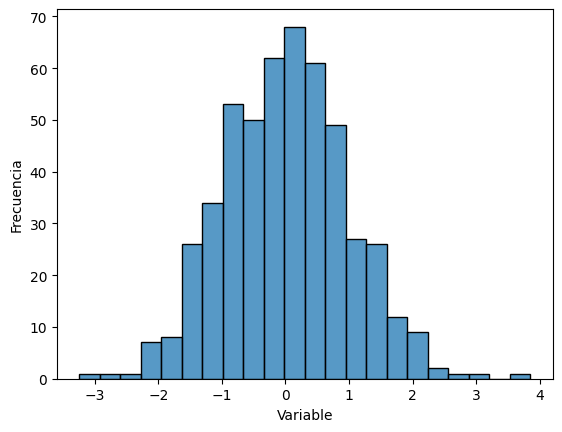

In [2]:
import seaborn as sns

# Histograma "var_1"
ax = sns.histplot(data=df['var_1'])
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia');

El primer paso para obtener un gráfico de densidad de probabilidad (o de distribución de probabilidad) es cambiando la escala del eje vertical, para que en lugar de frecuencia nos muestra probabilidades asociadas a cada intervalo.

Esto se logra fácilmente agregando el parámetro `stat = 'density'` a `histplot()`:

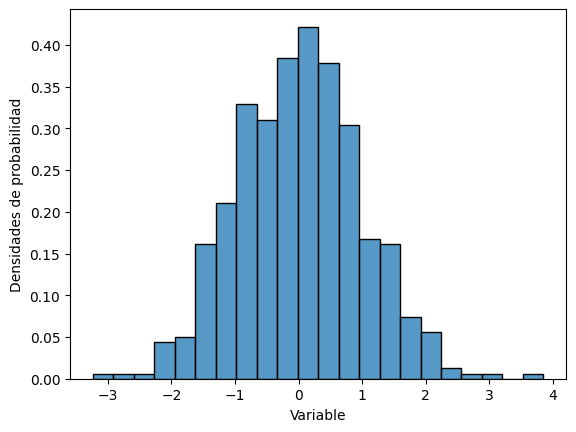

In [3]:
# Histograma "var_1" pero con densidades de probabilidad
ax = sns.histplot(data=df['var_1'], stat='density')
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad');

La altura de cada barra es ahora una **densidad de probabilidad**, es decir la probabilidad de ocurrencia por ancho del intervalo para cada intervalo.

Vemos que todas estas densidades están ahora entre 0 y 1 y si calculamos el área bajo la curva el resultado debería ser exactamente igual a 1.

Teniendo este histograma pero con densidades de probabilidad, lo que resta ahora es **estimar** la distribución teórica de los datos, para lo cual podemos usar el argumento `kde = True` en `histplot()`:

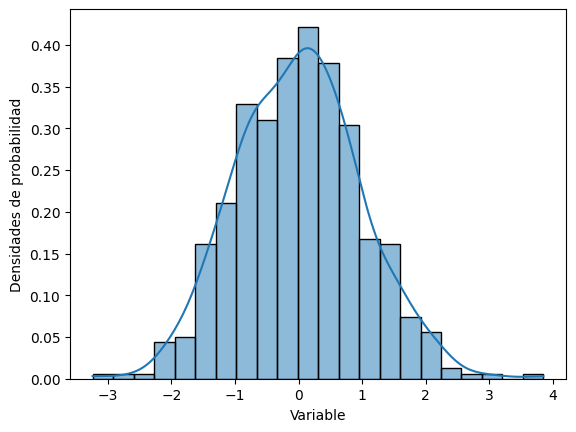

In [4]:
# Gráfico de densidad de probabilidad (o distribución de probabilidad) de la variable 1
ax = sns.histplot(data=df['var_1'], stat='density', kde=True)
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad');

La línea continua de color azul claro es la densidad de probabilidad de nuestra variable.

Es importante tener en cuenta que esta densidad de probabilidad **es independiente del número de bins usados para dibujar el histograma** (pues se calcula directamente a partir de los datos, sin considerar intervalos).

Por ejemplo si incrementamos el número de bins la densidad de probabilidad seguirá siendo la misma:

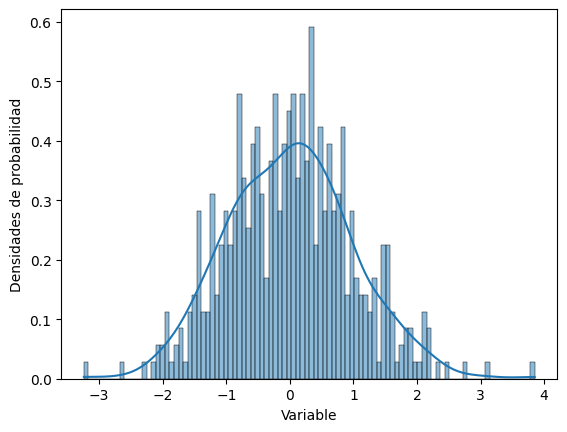

In [5]:
# Gráfico de densidad de probabilidad e histograma con 100 bins
ax = sns.histplot(data=df['var_1'], stat='density', kde=True, bins=100)
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad');

Y de igual forma si reducimos el número de bins la curva de densidad seguirá siendo la misma:

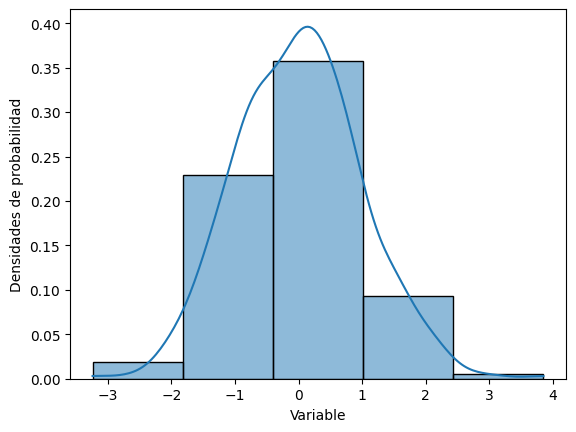

In [6]:
# Gráfico de densidad de probabilidad e histograma con 5 bins
ax = sns.histplot(data=df['var_1'], stat='density', kde=True, bins=5)
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad');

## 5. Opciones adicionales de visualización

Si queremos visualizar directamente la densidad de probabilidad y no el histograma podemos usar el método `distplot`:

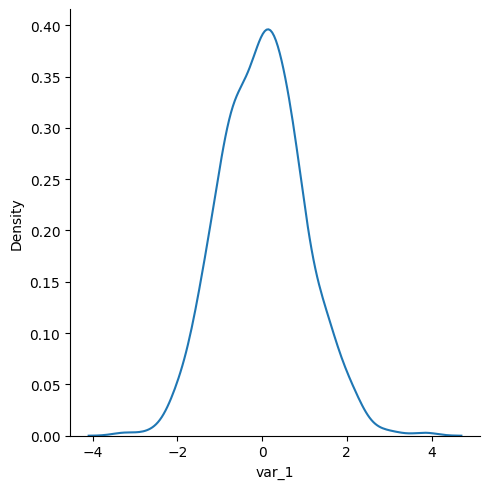

In [7]:
# Distribución de probabilidades
ax = sns.displot(df['var_1'], kind='kde')

Y podemos tomar lo mejor del *boxplot* (la posibilidad de ver los valores extremos, la mediana y el IQR) y superponerlo a la gráfica de la distribución de probabilidades usando **gráficos de violín** (`violinplot`):

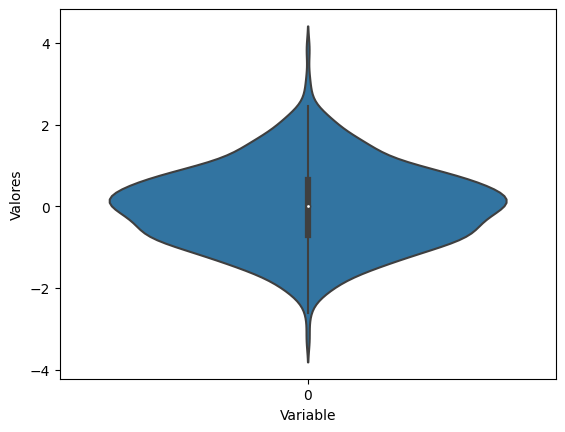

In [8]:
# Gráfico de violín para la variable 1
ax = sns.violinplot(data=df['var_1'])
ax.set_xlabel('Variable')
ax.set_ylabel('Valores');

En este caso:

- La pequeña caja de color negro corresponde al rango intercuartiles
- La mediana es el pequeño punto blanco dentro de esa caja
- Las líneas por encima y por debajo de la caja son los bigotes (*whiskers*)
- Las curvas de color azul (a izquierda y derecha) son la densidad de probabilidades estimada
- La escala vertical no indica densidades de probabilidad sino valores de la variable (asociados al *boxplot*)

Veamos la forma que tendrían los gráficos de violín para las variables 2 y 3:

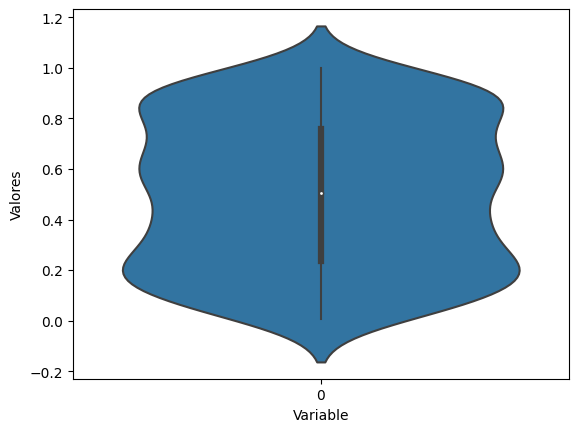

In [9]:
# Gráfico de violín para la variable 2
ax = sns.violinplot(data=df['var_2'])
ax.set_xlabel('Variable')
ax.set_ylabel('Valores');

Donde vemos que se trata de una distribución más uniforme pero a la vez simétrica alrededor de 0.5.

Y para la variable 3:

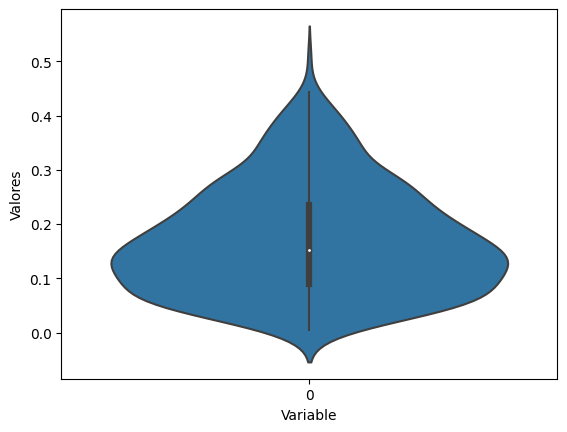

In [10]:
# Gráfico de violín para la variable 3
ax = sns.violinplot(data=df['var_3'], )
ax.set_xlabel('Variable')
ax.set_ylabel('Valores');

Y acá se evidencia el sesgo hacia valores bajos con una mediana del orden de 0.15 aproximadamente.

## 4. Aspectos a tener en cuenta

- Los gráficos de densidad en ocasiones pueden facilitar la interpretación de los datos en comparación con los histogramas.
- Podemos combinar los gráficos de densidad con los *boxplots* para de manera simultánea ver valores centrales y de dispersión junto con la distribución misma de los valores dentro de nuestra variable.